<a href="https://colab.research.google.com/github/CodeByJJY/JEDIS_LAB_DGIST/blob/main/Visual_Autoregressive_Original.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone $(printf 'https://github.com/%s.git' 'FoundationVision/VAR')
%cd VAR

!pip -q install huggingface_hub transformers typed-argument-parser

Cloning into 'VAR'...
remote: Enumerating objects: 265, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 265 (delta 144), reused 115 (delta 115), pack-reused 92 (from 1)
Receiving objects: 100% (265/265), 668.68 KiB | 9.69 MiB/s, done.
Resolving deltas: 100% (160/160), done.
/content/VAR


In [2]:
import os
import torch
import matplotlib.pyplot as plt

import dist
from models import build_vae_var
from huggingface_hub import hf_hub_download

# Single-GPU Colab initialization
dist.initialize()
device = dist.get_device()

print("device:", device)

# Original VAR-256 scale schedule
patch_nums = (1, 2, 3, 4, 5, 6, 8, 10, 13, 16)

MODEL_DEPTH = 16

# Download official checkpoints
vae_ckpt = hf_hub_download(
    repo_id="FoundationVision/var",
    filename="vae_ch160v4096z32.pth"
)

var_ckpt = hf_hub_download(
    repo_id="FoundationVision/var",
    filename=f"var_d{MODEL_DEPTH}.pth"
)

# Build official architecture
vae, var = build_vae_var(
    V=4096,
    Cvae=32,
    ch=160,
    share_quant_resi=4,
    device=device,
    patch_nums=patch_nums,
    num_classes=1000,
    depth=MODEL_DEPTH,
    shared_aln=False,

    # Colab에서 optional flash/xformers dependency 문제 방지
    flash_if_available=False,
    fused_if_available=False,
)

vae.load_state_dict(
    torch.load(vae_ckpt, map_location="cpu"),
    strict=True,
)

var.load_state_dict(
    torch.load(var_ckpt, map_location="cpu"),
    strict=True,
)

vae.eval()
var.eval()

for p in vae.parameters():
    p.requires_grad_(False)

for p in var.parameters():
    p.requires_grad_(False)

print("VAR loaded.")
print("scales:", patch_nums)

[dist initialize] cuda is not available, use cpu instead


device: cpu


vae_ch160v4096z32.pth: reconstructing file:   0%|          |  0.00B /  436MB            

vae_ch160v4096z32.pth: downloading bytes:           |  0.00B            

var_d16.pth: reconstructing file:   0%|          |  0.00B / 1.24GB            

var_d16.pth: downloading bytes:           |  0.00B            


[constructor]  ==== flash_if_available=False (0/16), fused_if_available=False (fusing_add_ln=0/16, fusing_mlp=0/16) ==== 
    [VAR config ] embed_dim=1024, num_heads=16, depth=16, mlp_ratio=4.0
    [drop ratios ] drop_rate=0.0, attn_drop_rate=0.0, drop_path_rate=0.0666667 (tensor([0.0000, 0.0044, 0.0089, 0.0133, 0.0178, 0.0222, 0.0267, 0.0311, 0.0356,
        0.0400, 0.0444, 0.0489, 0.0533, 0.0578, 0.0622, 0.0667]))

[init_weights] VAR with init_std=0.0180422
VAR loaded.
scales: (1, 2, 3, 4, 5, 6, 8, 10, 13, 16)


In [3]:
def generate_with_intermediate_latents(
    label=88,       # ImageNet class 88 = macaw
    seed=0,
    cfg=1.5,
    top_k=900,
    top_p=0.96,
):
    """
    Runs the ORIGINAL VAR autoregressive inference,
    while recording cumulative VAE latent f_hat after every scale.
    """

    quantizer = var.vae_quant_proxy[0]

    # Original official function
    original_fn = quantizer.get_next_autoregressive_input

    records = []

    # Hook
    def hooked_fn(si, SN, f_hat, h_BChw):

        # Run original VAR logic
        new_f_hat, next_token_map = original_fn(
            si, SN, f_hat, h_BChw
        )

        # Save intermediate tensors
        records.append({
            "step": si + 1,
            "patch_num": var.patch_nums[si],

            # sampled token embedding at this scale
            "scale_embedding": h_BChw.detach().float().cpu().clone(),

            # cumulative latent after adding this scale
            "f_hat": new_f_hat.detach().float().cpu().clone(),
        })

        return new_f_hat, next_token_map

    # Temporarily replace the function
    quantizer.get_next_autoregressive_input = hooked_fn

    try:
        with torch.inference_mode():

            final_img = var.autoregressive_infer_cfg(
                B=1,
                label_B=label,
                g_seed=seed,
                cfg=cfg,
                top_k=top_k,
                top_p=top_p,
                more_smooth=False,
            )

    finally:
        # 반드시 원래 함수로 복구
        quantizer.get_next_autoregressive_input = original_fn

    return final_img.cpu(), records

In [4]:
final_img, records = generate_with_intermediate_latents(
    label=88,
    seed=42,
    cfg=1.5,
    top_k=900,
    top_p=0.96,
)

print("Number of scales:", len(records))

for r in records:
    print(
        f"Step {r['step']:2d} | "
        f"scale = {r['patch_num']}x{r['patch_num']} | "
        f"f_hat = {tuple(r['f_hat'].shape)} | "
        f"scale_embedding = {tuple(r['scale_embedding'].shape)}"
    )

Number of scales: 10
Step  1 | scale = 1x1 | f_hat = (1, 32, 16, 16) | scale_embedding = (1, 32, 1, 1)
Step  2 | scale = 2x2 | f_hat = (1, 32, 16, 16) | scale_embedding = (1, 32, 2, 2)
Step  3 | scale = 3x3 | f_hat = (1, 32, 16, 16) | scale_embedding = (1, 32, 3, 3)
Step  4 | scale = 4x4 | f_hat = (1, 32, 16, 16) | scale_embedding = (1, 32, 4, 4)
Step  5 | scale = 5x5 | f_hat = (1, 32, 16, 16) | scale_embedding = (1, 32, 5, 5)
Step  6 | scale = 6x6 | f_hat = (1, 32, 16, 16) | scale_embedding = (1, 32, 6, 6)
Step  7 | scale = 8x8 | f_hat = (1, 32, 16, 16) | scale_embedding = (1, 32, 8, 8)
Step  8 | scale = 10x10 | f_hat = (1, 32, 16, 16) | scale_embedding = (1, 32, 10, 10)
Step  9 | scale = 13x13 | f_hat = (1, 32, 16, 16) | scale_embedding = (1, 32, 13, 13)
Step 10 | scale = 16x16 | f_hat = (1, 32, 16, 16) | scale_embedding = (1, 32, 16, 16)


In [5]:
@torch.no_grad()
def decode_fhat(f_hat_cpu):

    f_hat = f_hat_cpu.to(device)

    img = vae.fhat_to_img(f_hat)

    # [-1, 1] -> [0, 1]
    img = (img + 1.0) * 0.5
    img = img.clamp(0, 1)

    return img.cpu()


stage_images = []

for r in records:
    img = decode_fhat(r["f_hat"])
    stage_images.append(img)

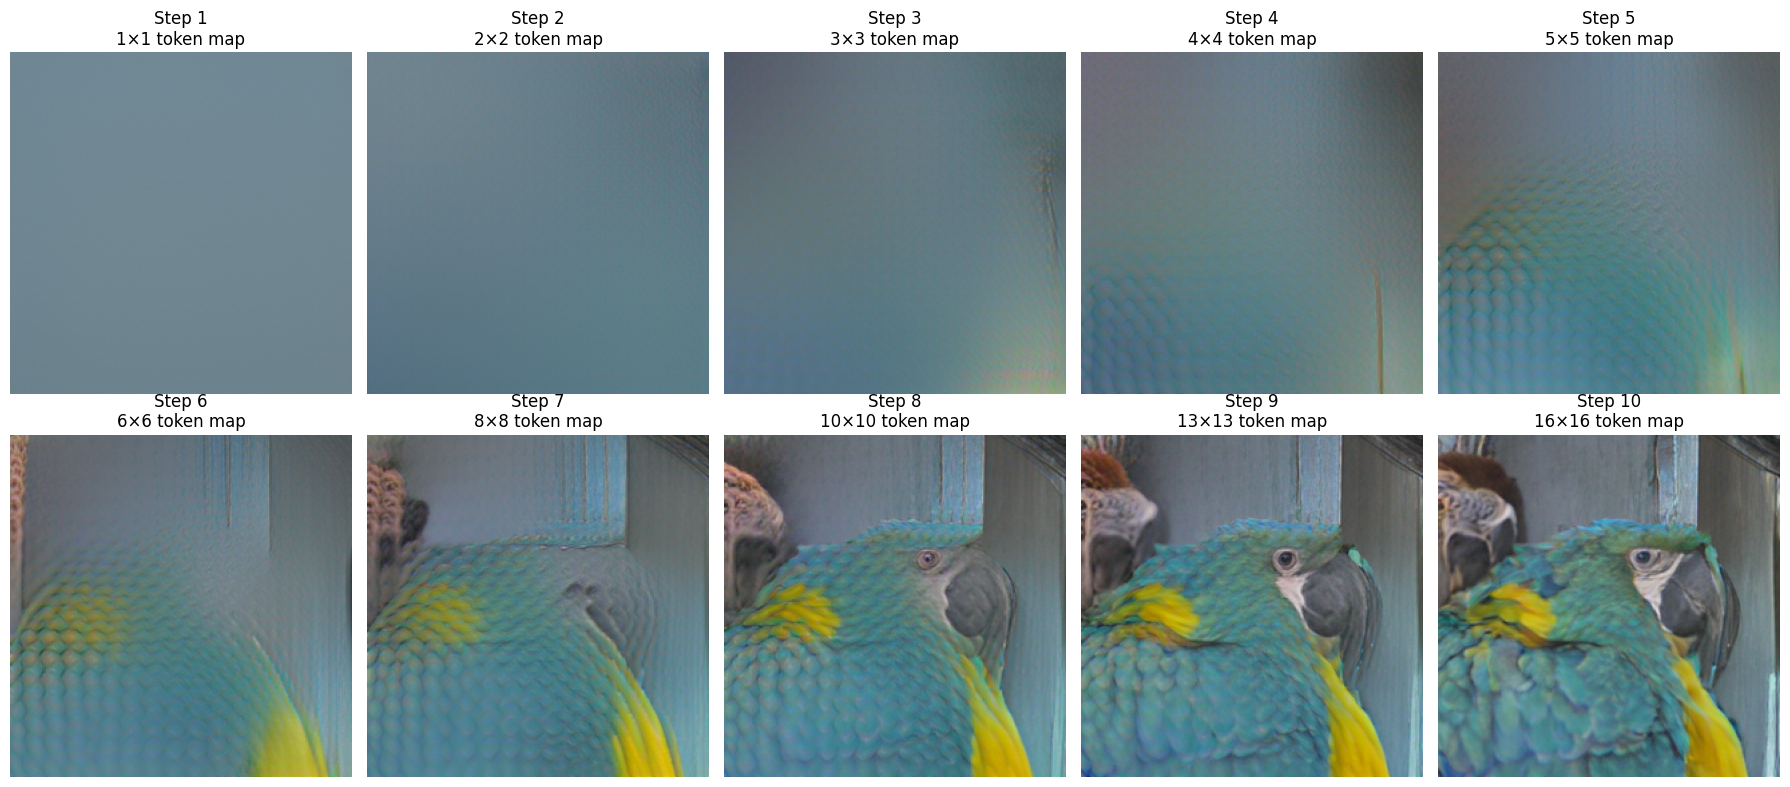

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for ax, img, r in zip(axes.flatten(), stage_images, records):

    x = img[0].permute(1, 2, 0).numpy()

    ax.imshow(x)
    ax.set_title(
        f"Step {r['step']}\n"
        f"{r['patch_num']}×{r['patch_num']} token map"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

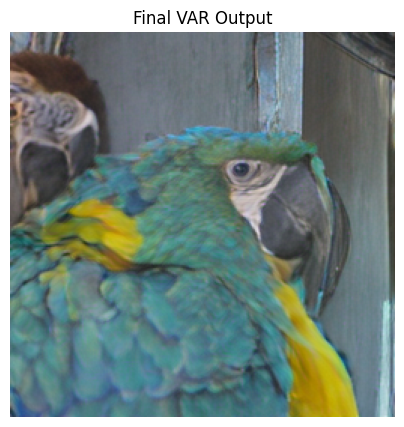

In [7]:
plt.figure(figsize=(5, 5))

plt.imshow(
    final_img[0]
    .permute(1, 2, 0)
    .clamp(0, 1)
    .numpy()
)

plt.title("Final VAR Output")
plt.axis("off")
plt.show()

In [8]:
deltas = []

prev = torch.zeros_like(records[0]["f_hat"])

for r in records:

    current = r["f_hat"]

    delta = current - prev

    # channel RMS magnitude
    magnitude = torch.sqrt(
        torch.mean(delta ** 2, dim=1)
    )

    deltas.append(magnitude)

    prev = current

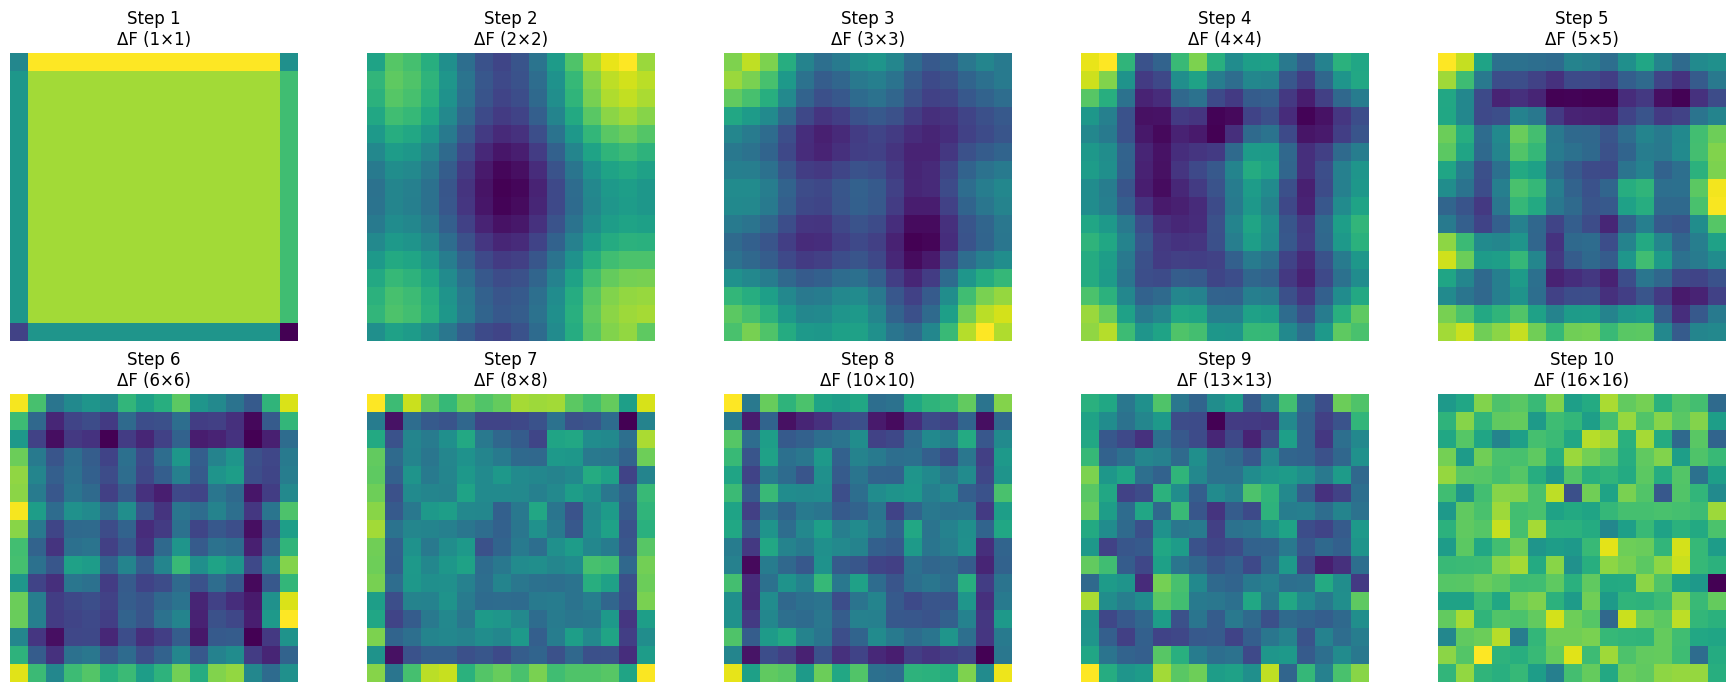

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for ax, d, r in zip(axes.flatten(), deltas, records):

    ax.imshow(d[0].numpy())

    ax.set_title(
        f"Step {r['step']}\n"
        f"ΔF ({r['patch_num']}×{r['patch_num']})"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()